# Object Detection for Mouse–Object Interaction Analysis

## Learning Objectives
- Detect static objects in an experimental frame using OpenCV
- Extract object centers and boundaries **in the same coordinate space as DLC CSV output**
- Measure proximity between mouse body parts (from DLC) and objects
- Define interaction bouts based on distance thresholds

> **Why same coordinate space?**  
> DeepLabCut outputs pixel coordinates `(x, y)` where `(0,0)` is the **top-left** of the frame,  
> x increases rightward, y increases downward. OpenCV uses the same convention by default.  
> This means object centers detected here can be directly compared to DLC keypoints!


In [ ]:
# Install required packages (already available on Colab, just confirming)
!pip install opencv-python-headless matplotlib numpy pandas --quiet
print("✓ Packages ready")


In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

print("✓ Imports successful")
print(f"  OpenCV version: {cv2.__version__}")


✓ Imports successful
  OpenCV version: 4.13.0


## Part 1: Load Your Experimental Frame

The frame must come from **the same video** your DLC CSV was generated from — so the pixel coordinates match exactly.

Upload your frame or load from Google Drive:


  Shape (height, width, channels): (528, 535, 3)
  Coordinate range: x=[0, 534], y=[0, 527]


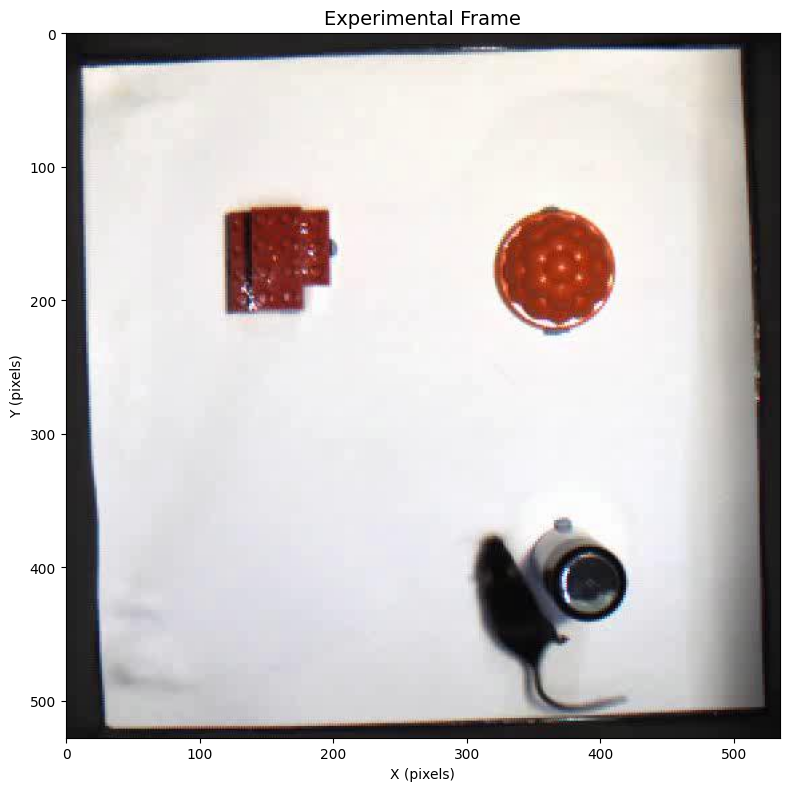

In [ ]:
# ─────────────────────────────────────────────
# OPTION A: Upload directly in Colab
# ─────────────────────────────────────────────
# from google.colab import files

# print("Upload your frame image (JPG or PNG):")
# uploaded = files.upload()
# frame_path = list(uploaded.keys())[0]

# ─────────────────────────────────────────────
# OPTION B: Load from Google Drive path
# ─────────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# frame_path = '/content/drive/MyDrive/YOUR_FOLDER/frame.jpg'

# Load image

import cv2
import urllib.request

# Use the raw GitHub URL (replace /blob/ with /raw/)
url = "https://raw.githubusercontent.com/miaowangcissy/animal_behavior_analysis_in_python/main/data/object_recg/extracted_frame.jpg"

# Fetch and decode the image
req = urllib.request.urlopen(url)
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
img_bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# img_bgr = cv2.imread('/Users/miao/Documents/phd/behavioral_python/animal_behavior_analysis_in_python/data/object_recg/YZ04-20240604-trial7.ExtractFrameFromAvi.jpg')
# img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# print(f"✓ Image loaded: {frame_path}")
print(f"  Shape (height, width, channels): {img_rgb.shape}")
print(f"  Coordinate range: x=[0, {img_rgb.shape[1]-1}], y=[0, {img_rgb.shape[0]-1}]")

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.title("Experimental Frame", fontsize=14)
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.tight_layout()
plt.show()


## Part 2: Detecting Objects with Color Segmentation (HSV Masking)

### Why HSV instead of RGB?

In RGB, a "red" color at different lighting conditions changes all three channels unpredictably.  
In **HSV** (Hue, Saturation, Value), the *color identity* is encoded in just **Hue**, making it much more robust to lighting changes:

$$\text{HSV} = (H, S, V) \quad H \in [0°, 360°], \; S, V \in [0, 1]$$

In OpenCV, H is scaled to **[0, 179]**, S and V to **[0, 255]**.

| Color | Hue range (OpenCV) |
|-------|--------------------|
| Red | 0–15 **and** 160–179 (wraps around!) |
| Green | 40–80 |
| Blue | 100–130 |

**For the reddish-brown objects** in your arena:
- Use two masks (low-hue + high-hue) and combine with `bitwise_or`
- Clean up noise with **morphological operations** (close gaps, remove specks)


Found 2 red/brown object(s):
  Object 1: center=(155, 167), bbox=(119, 131, 198, 209), area=5403 px²
  Object 2: center=(364, 177), bbox=(321, 133, 411, 223), area=6182 px²


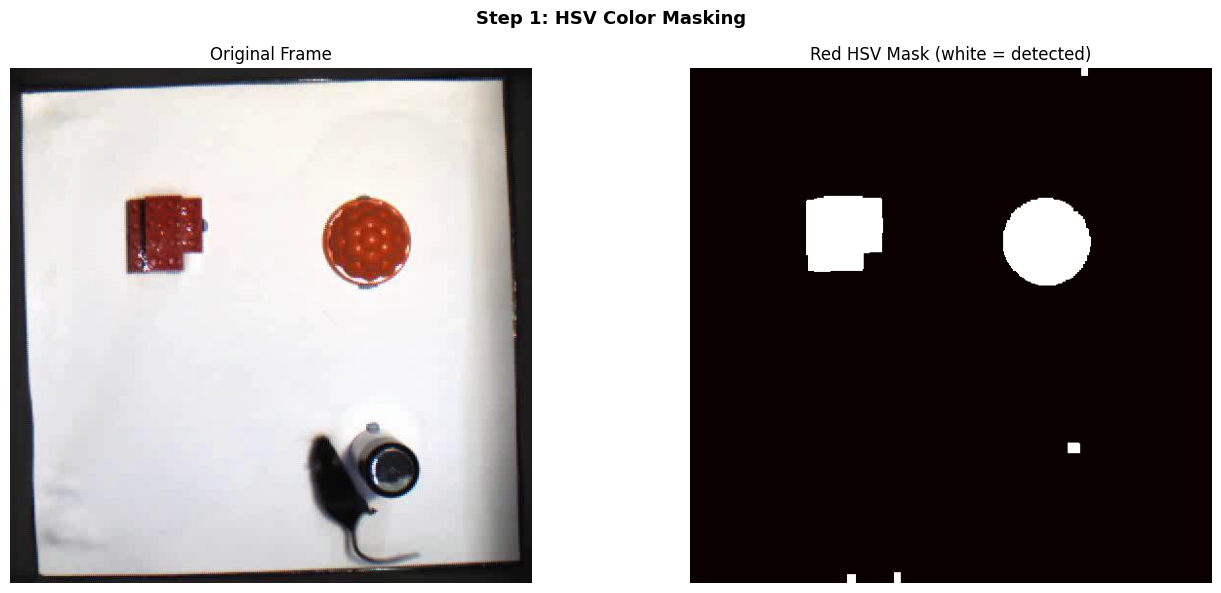

In [3]:
# ─────────────────────────────────────────────
# FUNCTION: Detect Red/Brown Objects via HSV Color Masking
# ─────────────────────────────────────────────

def detect_red_objects(img_bgr, min_area=500, max_n_objects=2,
                       lower1=(0, 60, 40), upper1=(15, 255, 200),
                       lower2=(160, 60, 40), upper2=(180, 255, 200)):
    """
    Detect reddish/brown objects in an image using HSV color masking.

    Parameters
    ----------
    img_bgr : np.ndarray
        BGR image loaded with cv2.imread()
    min_area : int
        Minimum contour area in pixels² (filters noise)
    max_n_objects : int
        Keep only the N largest objects found
    lower1/upper1 : tuple
        HSV range for low-hue red (0–15)
    lower2/upper2 : tuple
        HSV range for high-hue red (160–180)

    Returns
    -------
    objects : list of dict
        Each dict has keys: 'center', 'bbox', 'area', 'contour'
    red_mask : np.ndarray
        Binary mask showing detected regions
    """
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Create two masks for red hue (wraps around in HSV)
    mask_low  = cv2.inRange(hsv, np.array(lower1), np.array(upper1))
    mask_high = cv2.inRange(hsv, np.array(lower2), np.array(upper2))
    red_mask  = cv2.bitwise_or(mask_low, mask_high)

    # Morphological cleanup: close small gaps, remove tiny blobs
    kernel = np.ones((7, 7), np.uint8)
    red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_CLOSE, kernel)  # fill holes
    red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN,  kernel)  # remove noise

    # Find contours
    contours, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter by area and keep largest N
    valid = [c for c in contours if cv2.contourArea(c) > min_area]
    valid = sorted(valid, key=cv2.contourArea, reverse=True)[:max_n_objects]

    # Extract properties
    objects = []
    for c in valid:
        M = cv2.moments(c)
        if M['m00'] == 0:
            continue
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        x, y, bw, bh = cv2.boundingRect(c)
        objects.append({
            'center': (cx, cy),
            'bbox': (x, y, x + bw, y + bh),
            'area': cv2.contourArea(c),
            'contour': c
        })

    # Sort left-to-right by x coordinate
    objects = sorted(objects, key=lambda o: o['center'][0])
    return objects, red_mask


# Run it!
red_objects, red_mask = detect_red_objects(img_bgr)

print(f"Found {len(red_objects)} red/brown object(s):")
for i, obj in enumerate(red_objects):
    print(f"  Object {i+1}: center={obj['center']}, bbox={obj['bbox']}, area={obj['area']:.0f} px²")

# Visualize the mask
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_rgb)
axes[0].set_title("Original Frame")
axes[0].axis('off')
axes[1].imshow(red_mask, cmap='hot')
axes[1].set_title("Red HSV Mask (white = detected)")
axes[1].axis('off')
plt.suptitle("Step 1: HSV Color Masking", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Part 3: Detecting the Cylindrical Object (Hough Circle Transform)

The white cylinder is tricky — it blends with the white background in color space.  
Instead, we exploit its **circular shape** using the **Hough Circle Transform**.

### How it works

The Hough transform accumulates "votes" for circle centers. For each edge pixel at $(x_0, y_0)$, every possible circle center $(a, b)$ at radius $r$ satisfying:

$$(x_0 - a)^2 + (y_0 - b)^2 = r^2$$

gets a vote. Peaks in the accumulator = detected circles.

**Key parameters:**
- `param1`: Canny edge detection sensitivity (higher = fewer edges)
- `param2`: Accumulator threshold (lower = more circles, possibly false positives)
- `minRadius`, `maxRadius`: Expected size range in pixels


In [4]:
# ─────────────────────────────────────────────
# FUNCTION: Detect Cylindrical Object via Hough Circle Transform
# ─────────────────────────────────────────────

def detect_cylinder_object(img_bgr, search_region_y_fraction=0.5,
                            min_radius=15, max_radius=60,
                            hough_param1=50, hough_param2=28):
    """
    Detect a circular/cylindrical object using Hough Circle Transform.
    Searches only in the lower portion of the image to avoid false positives
    from the round red object.

    Parameters
    ----------
    img_bgr : np.ndarray
        BGR image
    search_region_y_fraction : float
        Only search in the bottom (1 - fraction) of the image
    min_radius, max_radius : int
        Expected circle radius range in pixels
    hough_param1 : int
        Canny edge threshold (higher = fewer, stronger edges detected)
    hough_param2 : int
        Circle detection threshold (lower = more circles found)

    Returns
    -------
    circle_info : dict or None
        Keys: 'center', 'bbox', 'area', 'radius'
    """
    h, w = img_bgr.shape[:2]
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (9, 9), 2)

    # Restrict search to lower portion (avoid confusing with top round red object)
    y_start = int(h * search_region_y_fraction)
    search_strip = blurred.copy()
    search_strip[:y_start, :] = 0  # black out upper region

    circles = cv2.HoughCircles(
        search_strip,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=60,
        param1=hough_param1,
        param2=hough_param2,
        minRadius=min_radius,
        maxRadius=max_radius
    )

    if circles is None:
        print("⚠ No cylinder detected. Try lowering hough_param2.")
        return None

    # Take the best candidate (highest accumulator score = first)
    cx, cy, r = [int(v) for v in circles[0][0]]

    return {
        'center': (cx, cy),
        'bbox':   (cx - r, cy - r, cx + r, cy + r),
        'area':   float(np.pi * r ** 2),
        'radius': r
    }


# Run it!
cylinder = detect_cylinder_object(img_bgr)

if cylinder:
    print(f"✓ Cylinder detected:")
    print(f"  Center (x, y): {cylinder['center']}")
    print(f"  Radius: {cylinder['radius']} pixels")
    print(f"  Bbox (x1,y1,x2,y2): {cylinder['bbox']}")
else:
    print("No cylinder found — adjust hough_param2 (try values 20–35)")


✓ Cylinder detected:
  Center (x, y): (390, 412)
  Radius: 28 pixels
  Bbox (x1,y1,x2,y2): (362, 384, 418, 440)


## Part 4: Combine All Objects into a Single Dictionary

We now have all 3 objects. Let's package them into a clean structure that matches your arena layout.


In [ ]:
# ─────────────────────────────────────────────
# COMBINE: Build final objects dict
# ─────────────────────────────────────────────

def detect_all_objects(img_bgr, object_names=None):
    """
    Detect all 3 arena objects and return a unified dictionary.

    Parameters
    ----------
    img_bgr : np.ndarray
        BGR image (the static arena frame, same video source as DLC)
    object_names : list of str, optional
        Custom names for [square, circle, cylinder].
        Defaults to ['object_1_square', 'object_2_circle', 'object_3_cylinder']

    Returns
    -------
    objects : dict
        {object_name: {'center': (x,y), 'bbox': (x1,y1,x2,y2), 'area': float}}
    """
    if object_names is None:
        object_names = ['object_1_square', 'object_2_circle', 'object_3_cylinder']

    red_obs, _ = detect_red_objects(img_bgr, min_area=500, max_n_objects=2)
    cylinder    = detect_cylinder_object(img_bgr)

    objects = {}

    # Map red objects: leftmost = square (index 0), rightmost = circle (index 1)
    for i, obj in enumerate(red_obs[:2]):
        if i < len(object_names):
            name = object_names[i]
            objects[name] = {
                'center': obj['center'],
                'bbox':   obj['bbox'],
                'area':   obj['area']
            }

    # Cylinder
    if cylinder and len(object_names) >= 3:
        objects[object_names[2]] = {
            'center': cylinder['center'],
            'bbox':   cylinder['bbox'],
            'area':   cylinder['area'],
            'radius': cylinder['radius']
        }

    return objects


# ── Run ──
OBJECT_NAMES = ['object_1_square', 'object_2_circle', 'object_3_cylinder']
arena_objects = detect_all_objects(img_bgr, object_names=OBJECT_NAMES)

print("=" * 50)
print("ARENA OBJECTS — DLC Coordinate Space (pixels)")
print("=" * 50)
for name, info in arena_objects.items():
    cx, cy = info['center']
    print(f"\n  {name}:")
    print(f"    Center: x={cx}, y={cy}")
    print(f"    Bbox:   {info['bbox']}")

# Sanity check
assert len(arena_objects) == 3, f"Expected 3 objects, found {len(arena_objects)}"
print("\n✓ All 3 objects detected successfully!")

# save the object info for later use to csv 
object_info_df = pd.DataFrame.from_dict(arena_objects, orient='index')
# object_info_df.to_csv('arena_objects_info.csv')

ARENA OBJECTS — DLC Coordinate Space (pixels)

  object_1_square:
    Center: x=155, y=167
    Bbox:   (119, 131, 198, 209)

  object_2_circle:
    Center: x=364, y=177
    Bbox:   (321, 133, 411, 223)

  object_3_cylinder:
    Center: x=390, y=412
    Bbox:   (362, 384, 418, 440)

✓ All 3 objects detected successfully!


In [15]:
arena_objects

{'object_1_square': {'center': (155, 167),
  'bbox': (119, 131, 198, 209),
  'area': 5403.0},
 'object_2_circle': {'center': (364, 177),
  'bbox': (321, 133, 411, 223),
  'area': 6182.5},
 'object_3_cylinder': {'center': (390, 412),
  'bbox': (362, 384, 418, 440),
  'area': 2463.0086404143976,
  'radius': 28}}

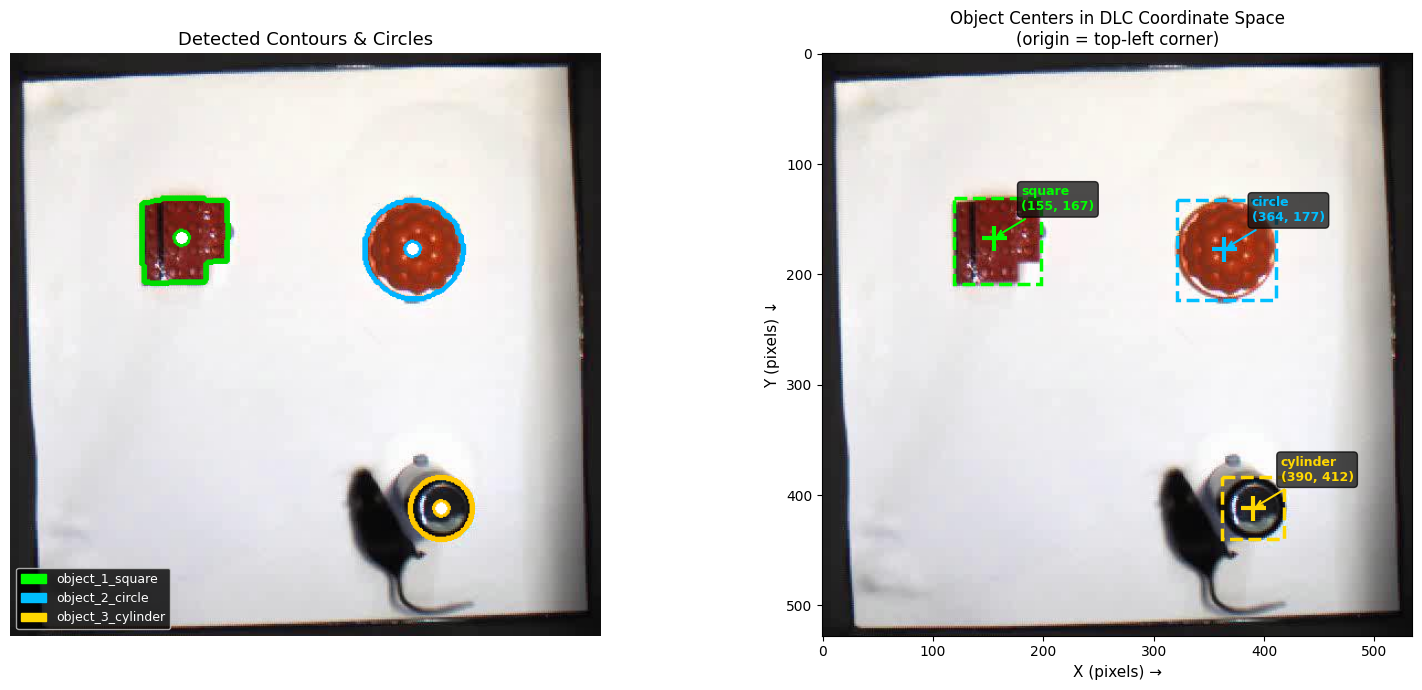

In [6]:
# ─────────────────────────────────────────────
# VISUALIZATION: All detected objects
# ─────────────────────────────────────────────

def visualize_objects(img_rgb, arena_objects):
    """Plot detected objects with bounding boxes and centers."""
    colors = ['lime', 'deepskyblue', 'gold']
    colors_bgr = [(0, 220, 0), (255, 180, 0), (0, 200, 255)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # --- Left: Contour overlay ---
    overlay = img_rgb.copy()
    overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)

    red_obs, _ = detect_red_objects(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    cylinder    = detect_cylinder_object(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))

    for i, obj in enumerate(red_obs[:2]):
        cv2.drawContours(overlay_bgr, [obj['contour']], -1, colors_bgr[i], 3)
    if cylinder:
        cv2.circle(overlay_bgr, cylinder['center'], cylinder['radius'], colors_bgr[2], 3)

    for i, (name, info) in enumerate(arena_objects.items()):
        cx, cy = info['center']
        cv2.circle(overlay_bgr, (cx, cy), 7, (255, 255, 255), -1)
        cv2.circle(overlay_bgr, (cx, cy), 7, colors_bgr[i], 2)

    axes[0].imshow(cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Detected Contours & Circles", fontsize=13)
    axes[0].axis('off')
    legend_patches = [mpatches.Patch(color=colors[i], label=n)
                      for i, n in enumerate(arena_objects.keys())]
    axes[0].legend(handles=legend_patches, loc='lower left', fontsize=9,
                   facecolor='black', labelcolor='white', framealpha=0.8)

    # --- Right: Coordinate-labeled plot ---
    axes[1].imshow(img_rgb)
    for i, (name, info) in enumerate(arena_objects.items()):
        cx, cy = info['center']
        x1, y1, x2, y2 = info['bbox']
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2.5,
                              edgecolor=colors[i], facecolor='none', linestyle='--')
        axes[1].add_patch(rect)
        axes[1].plot(cx, cy, '+', color=colors[i], markersize=18, markeredgewidth=3)
        short = name.split('_', 2)[-1] if '_' in name else name
        axes[1].annotate(f'{short}\n({cx}, {cy})', (cx, cy),
                         xytext=(cx + 25, cy - 25),
                         fontsize=9, fontweight='bold', color=colors[i],
                         bbox=dict(boxstyle='round,pad=0.3', facecolor='#111', alpha=0.75),
                         arrowprops=dict(arrowstyle='->', color=colors[i], lw=1.5))

    axes[1].set_title("Object Centers in DLC Coordinate Space\n(origin = top-left corner)", fontsize=12)
    axes[1].set_xlabel("X (pixels) →", fontsize=11)
    axes[1].set_ylabel("Y (pixels) ↓", fontsize=11)

    plt.tight_layout()
    plt.show()


visualize_objects(img_rgb, arena_objects)


##  Troubleshooting

| Problem | Likely Cause | Fix |
|---------|-------------|-----|
| Object not detected | Color outside HSV range | Print `hsv[y,x]` at object location; adjust `lower1/upper1` |
| Too many red blobs | Lighting reflections | Increase `min_area` or tighten HSV bounds |
| Cylinder not found | Low contrast edges | Lower `hough_param2` (try 20–25) |
| Wrong object paired as square vs circle | Sorting assumption wrong | Use `object_names` param to swap labels |
| Large distances always | Coordinate mismatch | Ensure frame = first frame of **same video** as DLC output |
| NaN distances | Low DLC likelihood | Lower `likelihood_threshold` in `load_dlc_csv` |

### Manual override — set object centers by hand

If auto-detection fails, you can always manually define centers:

```python
# Click on the image to find pixel coordinates, then:
arena_objects = {
    'object_1_square':   {'center': (156, 167), 'bbox': (119, 131, 198, 209), 'area': 5369},
    'object_2_circle':   {'center': (364, 177), 'bbox': (321, 133, 411, 223), 'area': 6112},
    'object_3_cylinder': {'center': (390, 412), 'bbox': (362, 384, 418, 440), 'area': 2463},
}
```
